In [2]:
import numpy as np
import pandas as pd
from copy import copy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

C:\Users\istiyak\AppData\Local\Temp\ipykernel_15228\3406820644.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
verus_df = pd.read_csv('./combined_true_df.csv', sep=',', index_col=0)
falsus_df = pd.read_csv('./combined_false_df.csv', sep=',', index_col=0)

df = pd.concat([verus_df, falsus_df])
df.shape

(1189215, 16)

In [3]:
df

,cascade_root_id,cascade_id,time_bucket,depth,size,max_breadth,virality,strongly_cc,weakly_cc,size_of_scc,avg_cluster_coef,density,layer_ratio,structural_heterogeneity,characteristic_distance,veracity
0,2879,102589,0,0,1,1,NaN,1,1,1,0.0,0.000000,1.000000,0.000000,-99999.000000,True
1,2881,102590,0,0,1,1,NaN,1,1,1,0.0,0.000000,1.000000,0.000000,-99999.000000,True
2,2882,102591,0,0,1,1,NaN,1,1,1,0.0,0.000000,1.000000,0.000000,-99999.000000,True
3,2883,102592,0,0,1,1,NaN,1,1,1,0.0,0.000000,1.000000,0.000000,-99999.000000,True
4,2884,102593,0,0,1,1,NaN,1,1,1,0.0,0.000000,1.000000,0.000000,-99999.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139115,990492,80999,67,4,56,37,0.035714,56,1,56,0.0,0.017857,1.432432,2.568982,1.046224,False
139116,990492,80999,68,4,56,37,0.035714,56,1,56,0.0,0.017857,1.432432,2.568982,1.046224,False
139117,990492,80999,69,4,56,37,0.035714,56,1,56,0.0,0.017857,1.432432,2.568982,1.046224,False
139118,990492,80999,70,4,56,37,0.035714,56,1,56,0.0,0.017857,1.432432,2.568982,1.046224,False


In [6]:
b = ['depth', 'size', 'max_breadth', 'virality', 'strongly_cc', 'weakly_cc', 'size_of_scc', 'density', 'layer_ratio', 'structural_heterogeneity', 'characteristic_distance']
len(b)

11

In [5]:
df['avg_cluster_coef'].unique()

array([0.])

In [8]:
verus_df.shape, falsus_df.shape

((199096, 16), (990119, 16))

In [9]:
df[(df.characteristic_distance != -99999) & (df.depth != 0)].shape

(906413, 16)

In [15]:
df[(df.characteristic_distance != -99999) & (df.depth != 0)].groupby(['time_bucket', 'veracity'])[['cascade_root_id']].count()

cascade_root_id
time_bucket veracity                 
0           False               17179
            True                 2854
1           False               20673
            True                 3471
2           False               18096
...                               ...
69          True                 1453
70          False                8073
            True                 1448
71          False                8028
            True                 1443

[144 rows x 1 columns]

In [4]:
active_features = 15
filtered_df = df[(df.time_bucket == 1) & (df.characteristic_distance != -99999) & (df.depth != 0)]
# filtered_df.shape
X = filtered_df.iloc[:,3:active_features]
Y = filtered_df.iloc[:,active_features]
# split data into train and test sets
seed = 7
test_size = 0.15
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)

In [5]:
normalized_df = copy(X_train)
cd_first_quantile = np.quantile(normalized_df['characteristic_distance'], 0.25)
cd_third_quantile = np.quantile(normalized_df['characteristic_distance'], 0.75)
normalized_df['depth'] = np.log(normalized_df['depth'])
normalized_df['size'] = np.log(normalized_df['size'])
normalized_df['max_breadth'] = np.log(normalized_df['max_breadth'])
normalized_df['strongly_cc'] = np.log(normalized_df['strongly_cc'])
normalized_df['size_of_scc'] = np.log(normalized_df['size_of_scc'])
normalized_df['structural_heterogeneity'] = np.log(normalized_df['structural_heterogeneity'])
normalized_df['characteristic_distance'] = np.log(normalized_df['characteristic_distance'] + cd_first_quantile**2/cd_third_quantile)
normalized_df = normalized_df.drop(columns=['avg_cluster_coef'], axis=1) 
normalized_df = normalized_df.drop(['weakly_cc'], axis=1)

scaler = StandardScaler().set_output(transform="pandas")
scaled_X_train = scaler.fit_transform(normalized_df)

<Axes: >

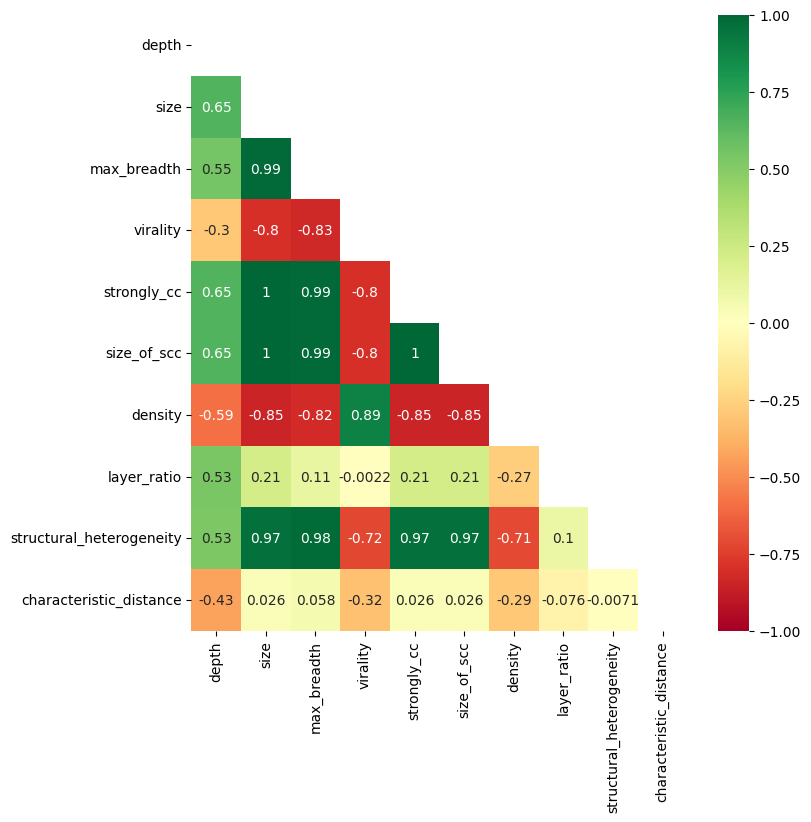

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
mask = np.triu(np.ones_like(scaled_X_train.corr(), dtype=bool))
sns.heatmap(scaled_X_train.corr(method='pearson', numeric_only = True), annot=True, mask=mask, vmin=-1, vmax=1, cmap ='RdYlGn')

In [6]:
# load statmodels functions
from statsmodels.stats.outliers_influence import variance_inflation_factor

# compute the vif for all given features
def compute_vif(df, considered_features):
    
    X = df[considered_features]
    # the calculation of variance inflation requires a constant
    X['intercept'] = 1
    
    # create dataframe to store vif values
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif = vif[vif['Variable']!='intercept']
    return vif

considered_features = list(scaled_X_train.columns)
considered_features.remove('size')
considered_features.remove('strongly_cc')

considered_features.remove('max_breadth')
considered_features.remove('size_of_scc')

# compute vif 
compute_vif(scaled_X_train, considered_features).sort_values('VIF', ascending=False)

C:\Users\istiyak\AppData\Local\Temp\ipykernel_12504\47309230.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['intercept'] = 1


,Variable,VIF
2,density,28.694655
1,virality,15.186443
0,depth,12.000237
5,characteristic_distance,4.842979
4,structural_heterogeneity,2.851927
3,layer_ratio,1.697389


Text(0.5, 1.0, 'Coefficients in the Elastic Net Model')

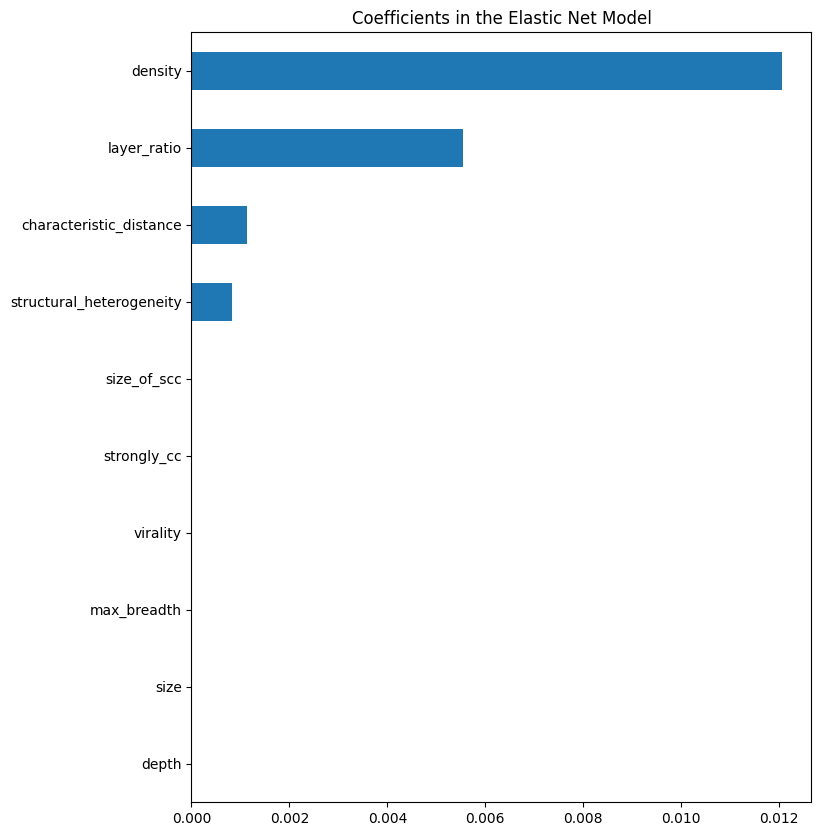

In [11]:
from sklearn.linear_model import ElasticNet
import matplotlib
import matplotlib.pyplot as plt
from numpy import arange

grid = {
    'alpha': [1e-3, 1e-2, 1e-1, 0.0, 1.0],
    'l1_ratio': arange(0, 1, 0.2)
}

model = ElasticNet()

clf = GridSearchCV(
    estimator=model,
    cv=5,
    refit="average_precision_score",
    param_grid=grid,
    scoring='average_precision',
    n_jobs=-1,
)

clf.fit(scaled_X_train, y_train)

coef = pd.Series(clf.best_estimator_.coef_, index = scaled_X_train.columns)
imp_coef = pd.concat([coef.sort_values().head(10)])

matplotlib.rcParams['figure.figsize'] = (8.0, 10.0)
imp_coef.plot(kind = "barh")
plt.title("Coefficients in the Elastic Net Model")

# arange(0, 1, 0.1)

In [12]:
import lightgbm as lgb

gbm = lgb.LGBMRegressor()
gbm.fit(scaled_X_train, y_train.astype('int32'))
gbm.booster_.feature_importance()

# importance of each attribute
fea_imp_ = pd.DataFrame({'cols':scaled_X_train.columns, 'feature_imp':gbm.feature_importances_})
fea_imp_.loc[fea_imp_.feature_imp > 0].sort_values(by=['feature_imp'], ascending = False)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001300 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1971
[LightGBM] [Info] Number of data points in the train set: 20522, number of used features: 10
[LightGBM] [Info] Start training from score 0.145941


,cols,feature_imp
1,size,714
8,structural_heterogeneity,577
7,layer_ratio,540
9,characteristic_distance,434
2,max_breadth,386
3,virality,251
0,depth,82
6,density,16


In [ ]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# define random forest classifier
rfc = RandomForestClassifier()
boruta_selector = BorutaPy(rfc, n_estimators='auto', verbose=2, random_state=1)
boruta_selector.fit(np.array(scaled_X_train), np.array(y_train)) 

selected_rf_features = pd.DataFrame({'Feature':list(scaled_X_train.columns),
                                      'Ranking':boruta_selector.ranking_})
selected_rf_features.sort_values(by='Ranking')